# R2-Dreamer: JAX vs PyTorch — Paper Benchmark

**Visualization notebook** — reads pre-computed results from
`output/comparison/r2dreamer_benchmark.json`.

To regenerate the data, run:
```bash
uv run python modules/r2dreamer/scripts/run_benchmark.py --train-steps 4000 --eval-episodes 10
```

| Variant | Framework | Rep Loss |
|---|---|---|
| **R2-Dreamer (JAX)** | JAX/Flax | Barlow Twins |
| **R2-Dreamer (PyTorch)** | PyTorch | Barlow Twins |
| **DreamerV3 (PyTorch)** | PyTorch | Reconstruction (decoder) |

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 120})

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
DATA_PATH = os.path.join(ROOT, 'output', 'comparison', 'r2dreamer_benchmark.json')
OUT_DIR = os.path.join(ROOT, 'output', 'comparison')

with open(DATA_PATH) as f:
    results = json.load(f)

print(f'Loaded results from {DATA_PATH}')
for name, r in results.items():
    n_steps = len(r.get('metrics_history', []))
    print(f'  {name}: {r["params"]:,} params, {n_steps} steps, {r["mean_step_ms"]:.1f} ms/step')

Loaded results from /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/output/comparison/r2dreamer_benchmark.json
  R2-Dreamer (JAX): 11,845,648 params, 4000 steps, 49.0 ms/step
  R2-Dreamer (PyTorch): 11,847,696 params, 4000 steps, 284.3 ms/step
  DreamerV3 (PyTorch): 10,498,259 params, 4000 steps, 294.1 ms/step


## 1. Performance Comparison

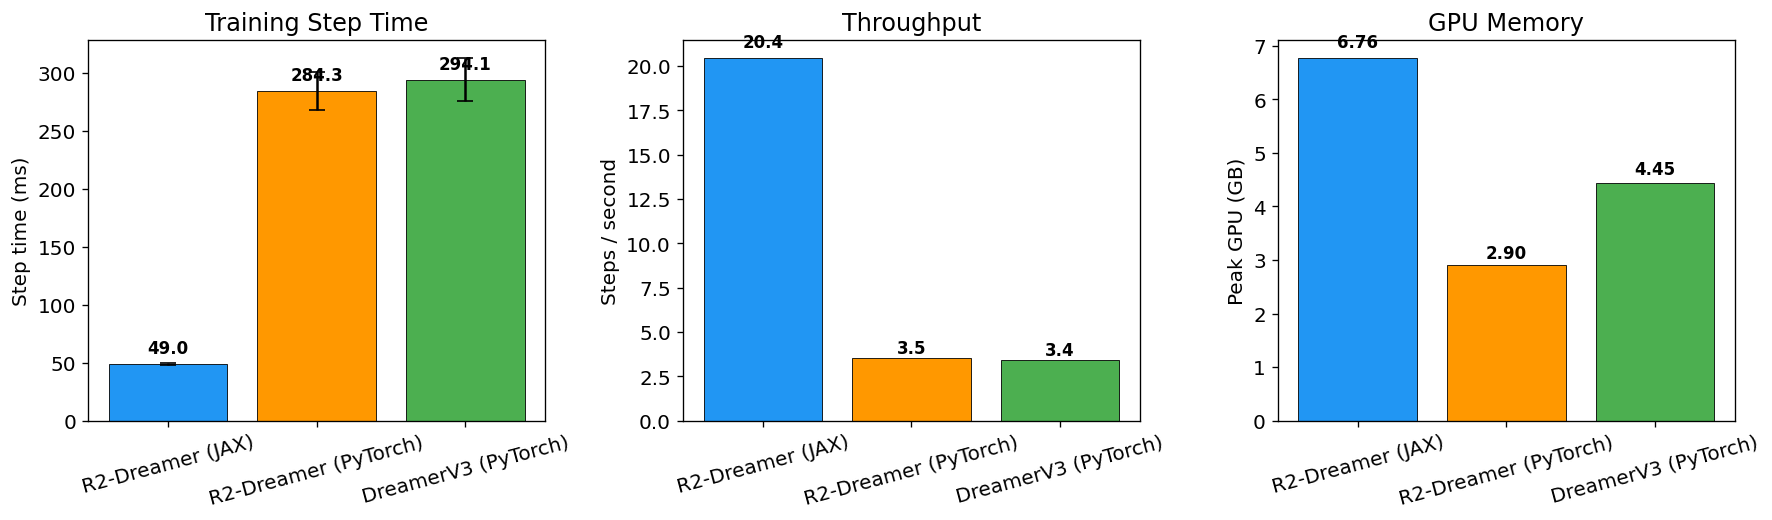

In [2]:
labels = list(results.keys())
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Step time
ax = axes[0]
means = [results[l]['mean_step_ms'] for l in labels]
stds = [results[l]['std_step_ms'] for l in labels]
bars = ax.bar(labels, means, yerr=stds, color=colors, capsize=5, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Step time (ms)')
ax.set_title('Training Step Time')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.3,
            f'{m:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

# Throughput
ax = axes[1]
sps = [results[l]['steps_per_sec'] for l in labels]
bars = ax.bar(labels, sps, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Steps / second')
ax.set_title('Throughput')
for bar, s in zip(bars, sps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f'{s:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

# GPU memory
ax = axes[2]
mems = [results[l]['peak_gpu_gb'] for l in labels]
bars = ax.bar(labels, mems, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Peak GPU (GB)')
ax.set_title('GPU Memory')
for bar, m in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f'{m:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_performance.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_performance.png'), bbox_inches='tight', dpi=200)
plt.show()

## 2. Loss Curves

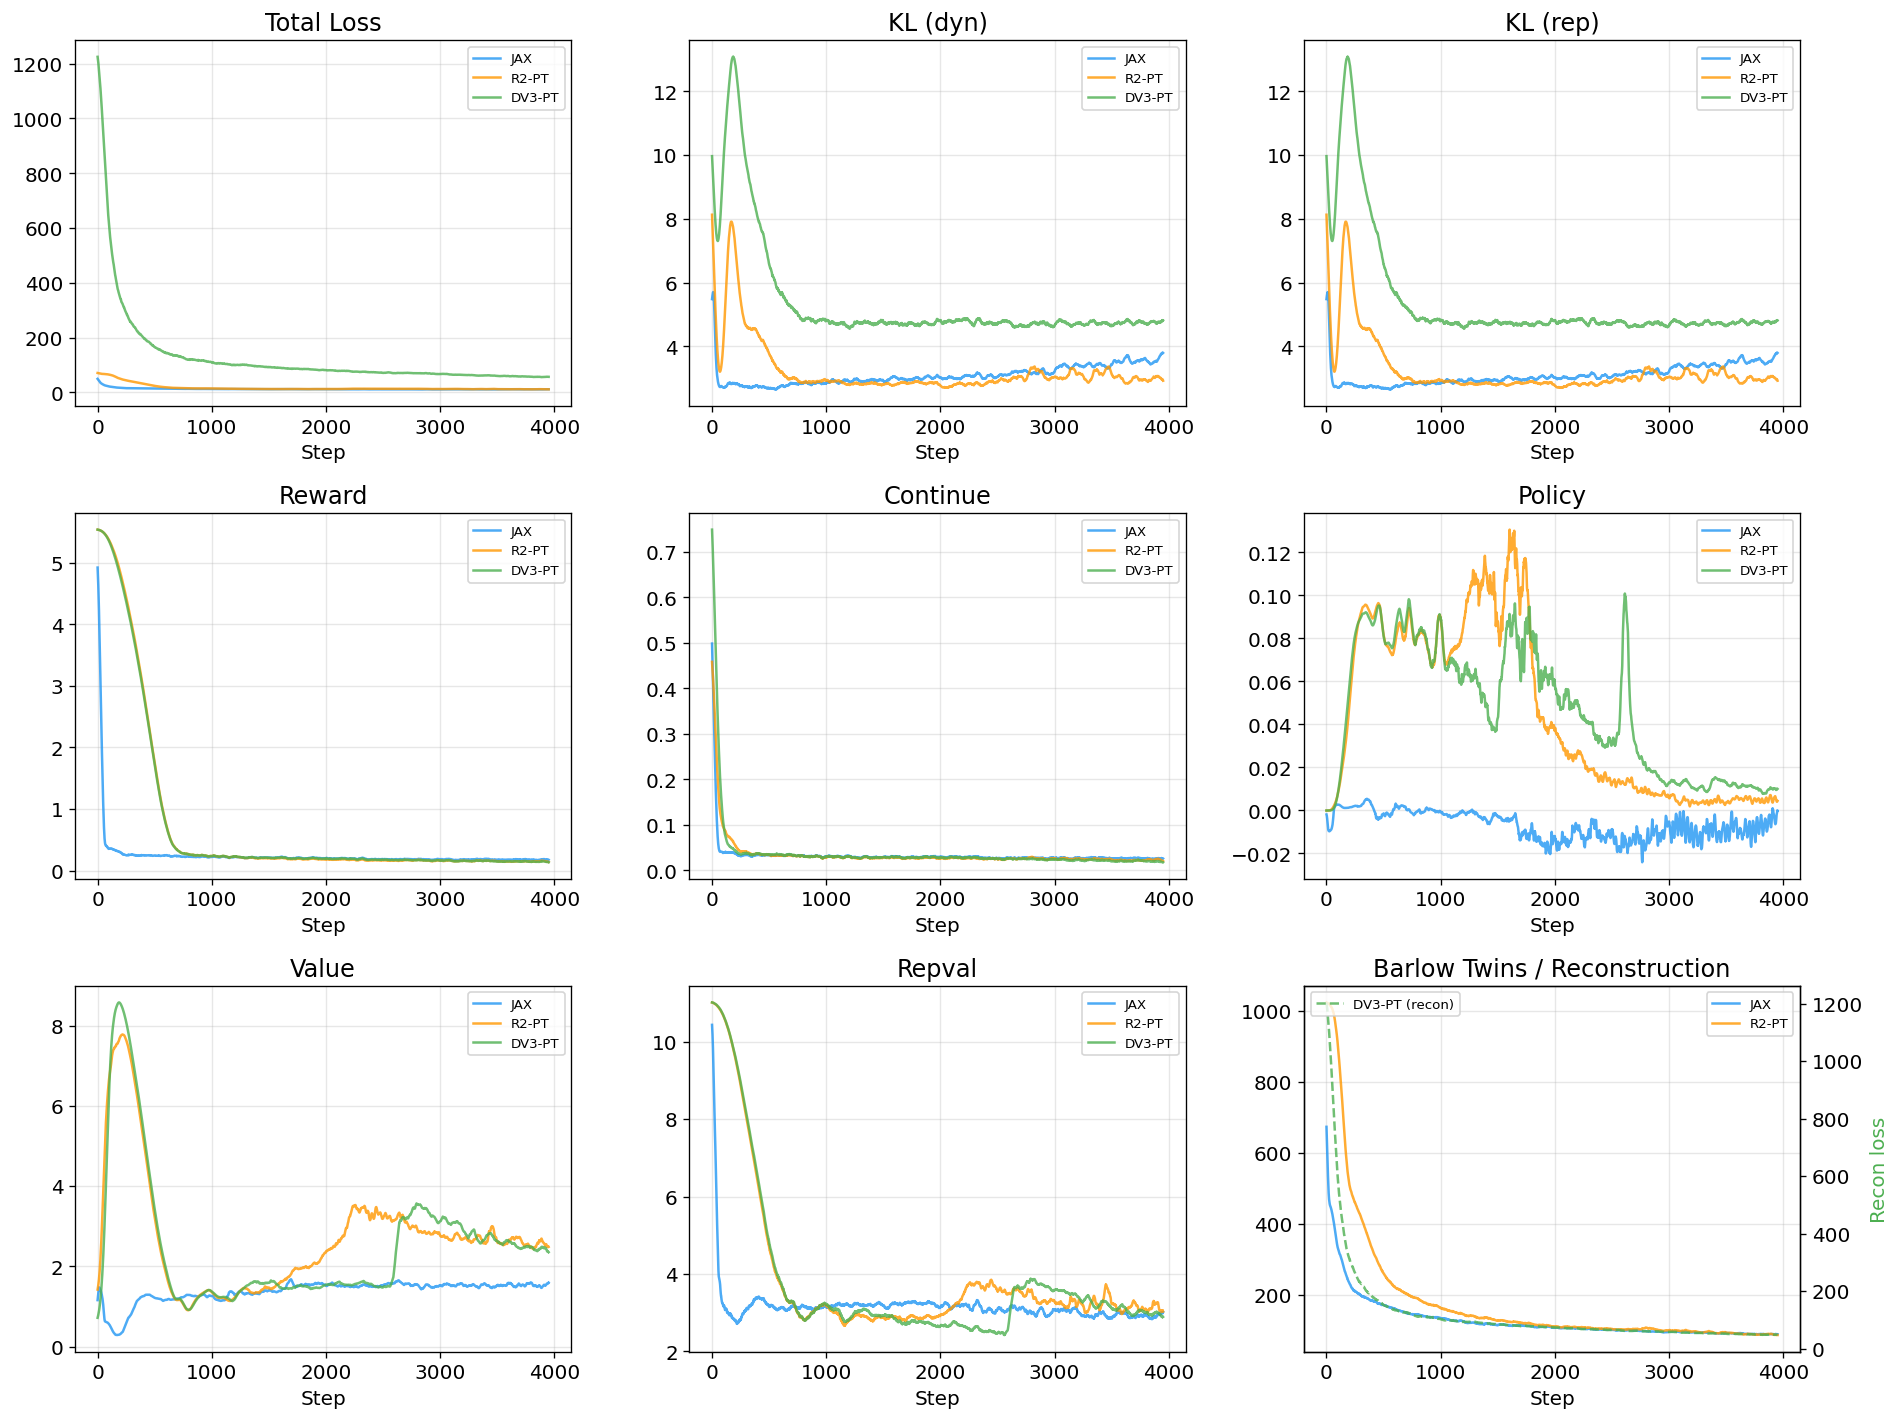

In [3]:
def smooth(values, window=50):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

def extract(history, key):
    vals = [m.get(key, m.get(f'loss/{key}', float('nan'))) for m in history]
    return np.array(vals)

variant_keys = list(results.keys())
short_labels = ['JAX', 'R2-PT', 'DV3-PT']

shared_losses = [
    ('KL (dyn)', 'loss/dyn'),
    ('KL (rep)', 'loss/rep'),
    ('Reward', 'loss/rew'),
    ('Continue', 'loss/con'),
    ('Policy', 'loss/policy'),
    ('Value', 'loss/value'),
    ('Repval', 'loss/repval'),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

# Total loss
ax = axes[0]
for i, vk in enumerate(variant_keys):
    hist = results[vk]['metrics_history']
    key = 'total_loss' if i == 0 else 'opt/loss'
    vals = extract(hist, key)
    if not np.all(np.isnan(vals)):
        ax.plot(smooth(vals), label=short_labels[i], color=colors[i], alpha=0.8)
ax.set_title('Total Loss')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Shared losses
for idx, (name, key) in enumerate(shared_losses):
    ax = axes[idx + 1]
    for i, vk in enumerate(variant_keys):
        vals = extract(results[vk]['metrics_history'], key)
        if not np.all(np.isnan(vals)):
            ax.plot(smooth(vals), label=short_labels[i], color=colors[i], alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Step')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Barlow / Reconstruction
ax = axes[8]
for i, vk in enumerate(variant_keys[:2]):
    vals = extract(results[vk]['metrics_history'], 'loss/barlow')
    if not np.all(np.isnan(vals)):
        ax.plot(smooth(vals), label=short_labels[i], color=colors[i], alpha=0.8)
if len(variant_keys) > 2:
    vals = extract(results[variant_keys[2]]['metrics_history'], 'loss/image')
    if not np.all(np.isnan(vals)):
        ax2 = ax.twinx()
        ax2.plot(smooth(vals), label='DV3-PT (recon)', color=colors[2], alpha=0.8, linestyle='--')
        ax2.set_ylabel('Recon loss', color=colors[2])
        ax2.legend(fontsize=8, loc='upper left')
ax.set_title('Barlow Twins / Reconstruction')
ax.set_xlabel('Step')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_losses.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_losses.png'), bbox_inches='tight', dpi=200)
plt.show()

## 3. Policy Evaluation

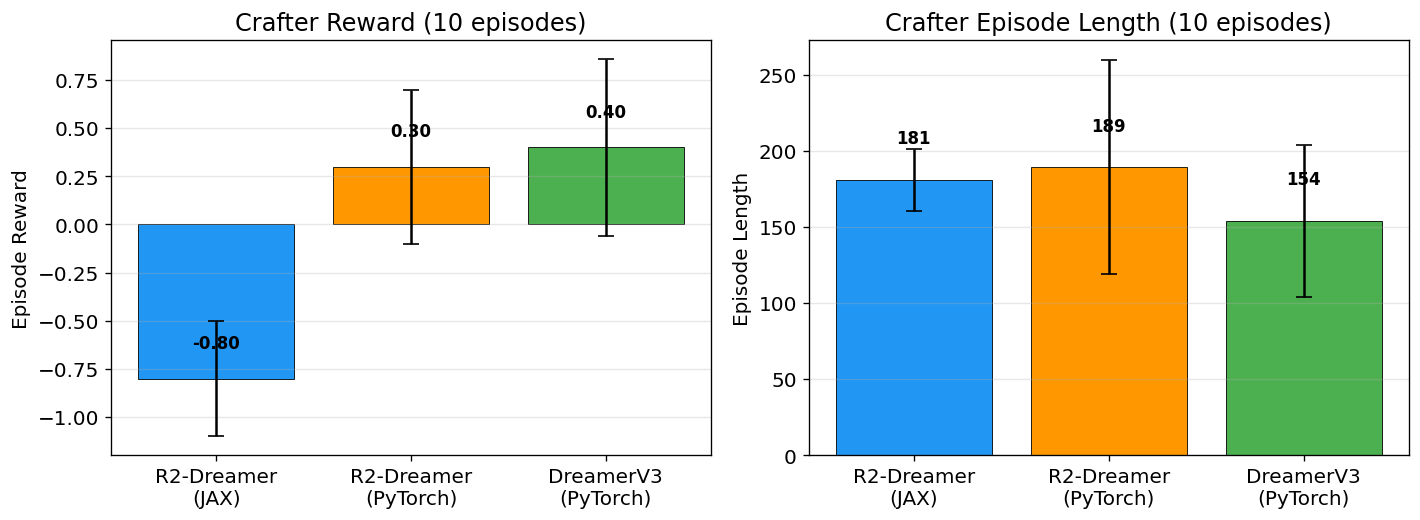

R2-Dreamer (JAX): ['-0.9', '-0.9', '-0.9', '-0.9', '-0.9', '0.1', '-0.9', '-0.9', '-0.9', '-0.9']
R2-Dreamer (PyTorch): ['0.1', '0.1', '0.1', '0.1', '0.1', '1.1', '0.1', '1.1', '0.1', '0.1']
DreamerV3 (PyTorch): ['1.1', '1.1', '1.1', '0.1', '0.1', '0.1', '0.1', '0.1', '0.1', '0.1']


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bar_labels = [l.replace(' (', '\n(') for l in results.keys()]

# Episode reward
ax = axes[0]
r_means = [np.mean(results[l].get('eval_rewards', [0])) for l in results]
r_stds = [np.std(results[l].get('eval_rewards', [0])) for l in results]
bars = ax.bar(bar_labels, r_means, yerr=r_stds, color=colors, capsize=5, edgecolor='black', linewidth=0.5)
for bar, m in zip(bars, r_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(r_stds)*0.3,
            f'{m:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
n_eps = len(list(results.values())[0].get('eval_rewards', []))
ax.set_ylabel('Episode Reward')
ax.set_title(f'Crafter Reward ({n_eps} episodes)')
ax.grid(True, alpha=0.3, axis='y')

# Episode length
ax = axes[1]
l_means = [np.mean(results[l].get('eval_lengths', [0])) for l in results]
l_stds = [np.std(results[l].get('eval_lengths', [0])) for l in results]
bars = ax.bar(bar_labels, l_means, yerr=l_stds, color=colors, capsize=5, edgecolor='black', linewidth=0.5)
for bar, m in zip(bars, l_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(l_stds)*0.3,
            f'{m:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Episode Length')
ax.set_title(f'Crafter Episode Length ({n_eps} episodes)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_eval_rewards.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'r2dreamer_eval_rewards.png'), bbox_inches='tight', dpi=200)
plt.show()

# Per-episode detail
for name in results:
    rews = results[name].get('eval_rewards', [])
    print(f'{name}: {[f"{r:.1f}" for r in rews]}')

## 4. Summary Table

In [5]:
r2_pt_ms = results.get('R2-Dreamer (PyTorch)', {}).get('mean_step_ms', 1)
print(f"{'Variant':<25} {'Params':>10} {'ms/step':>10} {'steps/s':>10} {'GPU (GB)':>10} {'Speedup':>10}")
print('-' * 80)
for name, r in results.items():
    sp = r2_pt_ms / r['mean_step_ms']
    print(f"{name:<25} {r['params']:>10,} {r['mean_step_ms']:>8.1f}ms {r['steps_per_sec']:>10.1f} {r['peak_gpu_gb']:>8.2f}GB {sp:>8.2f}x")

latex = r'''\begin{table}[h]
\centering
\caption{Training performance comparison on Crafter (batch\_size=16, seq\_len=64).}
\label{tab:r2dreamer-benchmark}
\begin{tabular}{lccccc}
\toprule
Variant & Params & ms/step & Steps/s & GPU (GB) & Speedup \\\\
\midrule
'''
for name, r in results.items():
    sp = r2_pt_ms / r['mean_step_ms']
    latex += f"{name} & {r['params']:,} & {r['mean_step_ms']:.1f} $\\pm$ {r['std_step_ms']:.1f} & {r['steps_per_sec']:.1f} & {r['peak_gpu_gb']:.2f} & {sp:.2f}$\\times$ \\\\\n"
latex += r'''\bottomrule
\end{tabular}
\end{table}'''
print('\n' + latex)

with open(os.path.join(OUT_DIR, 'r2dreamer_benchmark_table.tex'), 'w') as f:
    f.write(latex)
print('\nSaved: output/comparison/r2dreamer_benchmark_table.tex')

Variant                       Params    ms/step    steps/s   GPU (GB)    Speedup
--------------------------------------------------------------------------------
R2-Dreamer (JAX)          11,845,648     49.0ms       20.4     6.76GB     5.81x
R2-Dreamer (PyTorch)      11,847,696    284.3ms        3.5     2.90GB     1.00x
DreamerV3 (PyTorch)       10,498,259    294.1ms        3.4     4.45GB     0.97x

\begin{table}[h]
\centering
\caption{Training performance comparison on Crafter (batch\_size=16, seq\_len=64).}
\label{tab:r2dreamer-benchmark}
\begin{tabular}{lccccc}
\toprule
Variant & Params & ms/step & Steps/s & GPU (GB) & Speedup \\\\
\midrule
R2-Dreamer (JAX) & 11,845,648 & 49.0 $\pm$ 1.1 & 20.4 & 6.76 & 5.81$\times$ \\
R2-Dreamer (PyTorch) & 11,847,696 & 284.3 $\pm$ 16.5 & 3.5 & 2.90 & 1.00$\times$ \\
DreamerV3 (PyTorch) & 10,498,259 & 294.1 $\pm$ 18.4 & 3.4 & 4.45 & 0.97$\times$ \\
\bottomrule
\end{tabular}
\end{table}

Saved: output/comparison/r2dreamer_benchmark_table.tex
